In [1]:
#distance map PDB to HMM
from sequenceHandler import mapPDBToHMM
pdb_file = "1AAL.pdb"
chain_id = "A"
hmm_file = "PF00014.hmm"
hmm_file_2 = "None"        
output_map_file = "distance_map.txt"  

distance_map,map_index, alig_seq = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')
print(distance_map)
print(map_index)

FileNotFoundError: [Errno 2] No such file or directory: '1AAL.pdb'

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.show()

NameError: name 'distance_map' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
from sequenceHandler import  stockholm2fasta,filterSequenceByGapContent,do_DCA,get_pfam_msa, extract_scop_ids
from sequenceHandler import mapPDBToHMM
import pickle
import requests
from pathlib import Path
import gzip
import shutil
import subprocess

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


def _make_session():
    session = requests.Session()
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        status=5,
        backoff_factor=1.0,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET"]),
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=1, pool_maxsize=1)
    session.mount("https://", adapter)
    session.headers.update(
        {
            "User-Agent": "Mozilla/5.0",
            "Connection": "close",
            "Accept": "*/*",
        }
    )
    return session

# with open("pfam_list.txt", "r") as f:
#     pfam_ids = [line.strip() for line in f]


# for pfam_id in pfam_ids:
#     data={}
#     print(pfam_id)
i=198
while True:
    try:
        i+=1
        data={}
        pfam_id=f"PF00{i}"
        print(pfam_id)

        # Get the MSA in Stockholm format and save it to a file
        msa = get_pfam_msa(pfam_id, kind="full")
        out_sto = f'MSA/msa_{pfam_id}.sto'
        with open(out_sto, "wb") as f:
            f.write(msa)

        # Extract the PDB ID from the Stockholm file and download the corresponding PDB file
        pdb_id = extract_scop_ids(out_sto)
        print(pdb_id)
        if not pdb_id==[]:
            resp = requests.get(url=f"https://files.rcsb.org/download/{pdb_id[0].upper()}.pdb")
            out_pdb = f'PDB/{pfam_id}.pdb'
            with open(out_pdb, "wb") as f:
                f.write(resp.content)

            # Get the HMM file for the Pfam family
            accession = pfam_id
            out_dir="HMM"
            accession = accession.strip().upper()

            if not accession.startswith("PF") or len(accession) != 7:
                raise ValueError("Expected a Pfam accession like PF00042")

            out_dir = Path(out_dir)
            out_dir.mkdir(parents=True, exist_ok=True)

            gz_path = out_dir / f"{accession}.hmm.gz"
            hmm_path = out_dir / f"{accession}.hmm"

            url = f"https://www.ebi.ac.uk/interpro/api/entry/pfam/{accession}?annotation=hmm"

            # First try pure Python requests with retries
            try:
                session = _make_session()
                with session.get(url, stream=True, timeout=(20, 120)) as r:
                    r.raise_for_status()
                    with open(gz_path, "wb") as f:
                        for chunk in r.iter_content(chunk_size=1024 * 64):
                            if chunk:
                                f.write(chunk)

            except requests.exceptions.SSLError:
                # Fallback: use curl if available, which often succeeds where requests/OpenSSL fails
                curl = shutil.which("curl") or shutil.which("curl.exe")
                if not curl:
                    raise RuntimeError(
                        "SSL error from requests, and curl was not found on PATH."
                    )

                cmd = [
                    curl,
                    "-L",
                    "--fail",
                    "--retry",
                    "5",
                    "--retry-delay",
                    "2",
                    "--connect-timeout",
                    "20",
                    "-o",
                    str(gz_path),
                    url,
                ]
                subprocess.run(cmd, check=True)

            # Decompress .gz -> .hmm
            with gzip.open(gz_path, "rb") as fin, open(hmm_path, "wb") as fout:
                shutil.copyfileobj(fin, fout)    

            #contanct map of the PDB and sequence
            from sequenceHandler import mapPDBToHMM
            pdb_file = f"PDB/{pfam_id}.pdb"
            chain_id = "A"
            hmm_file = f"HMM/{pfam_id}.hmm"
            hmm_file_2 = "None"        
            output_map_file = "None"  

            distance_map,map_index,aligned_sequence = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')

            gap_count=0
            for letter in aligned_sequence:
                if letter=="-":
                    gap_count+=1
            print(f"Gap percentage = {gap_count/len(aligned_sequence)*100}%")
            if gap_count>len(aligned_sequence)/2:
                raise ValueError("The number of gap is more than half of the sequence")


            # Takes the MSA of the family, convert Stockholm to FASTA, filter sequences by gap content, and perform DCA
            out_fasta= f'MSA/msa_{pfam_id}.fasta' 
            stockholm2fasta(out_sto,out_fasta)
            number_of_sequence=filterSequenceByGapContent(out_fasta, 0.2, out_fasta)
            print(number_of_sequence)

            if number_of_sequence<50000:
                score_map = do_DCA(out_fasta)
                

                data = {
                    'sequence': aligned_sequence,
                    'distance_map': distance_map,
                    'dca': score_map
                }

                with open(f"Data/data_{pfam_id}.pkl", "wb") as f:
                    pickle.dump(data, f)
            else:
                print("Too much sequences")
        else:
            print(f"No SCOP found for {pfam_id}, skipped")
    except:
        print(f"Some error occurred in the sequence {pfam_id}")

PF00199
['7cat']


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8773.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 8864.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8955.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 9005.
  warnings.warn(


Gap percentage = 0.26109660574412535%
Original number of sequences  17658
Sequences after filtering :  14300
Filtered sequences saved to  MSA/msa_PF00199.fasta
14300
removing duplicate sequences... done: 14300 -> 13341
θ = 0.24741577735718107 threshold = 94.0
M = 13341 N = 383 Meff = 708.043085668102
preprocessing took 2.536576818 seconds
site = 1	 pl = 0.1541	 time = 4.0472	exit status = FTOL_REACHED
site = 2	 pl = 0.4714	 time = 8.6762	exit status = FTOL_REACHED
site = 3	 pl = 0.6339	 time = 9.1854	exit status = FTOL_REACHED
site = 4	 pl = 0.7328	 time = 9.7081	exit status = FTOL_REACHED
site = 5	 pl = 0.0704	 time = 4.2747	exit status = FTOL_REACHED
site = 6	 pl = 0.7806	 time = 10.0517	exit status = FTOL_REACHED
site = 7	 pl = 0.3624	 time = 7.8225	exit status = FTOL_REACHED
site = 8	 pl = 0.5433	 time = 8.8144	exit status = FTOL_REACHED
site = 9	 pl = 0.8647	 time = 9.6164	exit status = FTOL_REACHED
site = 10	 pl = 0.5963	 time = 9.8107	exit status = FTOL_REACHED
site = 11	 pl = 0

/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 9804.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 9891.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 9978.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 10343.
  warnings.warn(


Gap percentage = 4.37956204379562%
Original number of sequences  42196
Sequences after filtering :  39157
Filtered sequences saved to  MSA/msa_PF00205.fasta
39157
removing duplicate sequences... done: 39157 -> 36956
θ = 0.4579353759061206 threshold = 62.0
M = 36956 N = 137 Meff = 2162.418040572178
preprocessing took 10.823041364 seconds
site = 1	 pl = 0.8716	 time = 3.8822	exit status = FTOL_REACHED
site = 2	 pl = 1.5680	 time = 5.7713	exit status = FTOL_REACHED
site = 3	 pl = 1.7080	 time = 4.9975	exit status = FTOL_REACHED
site = 4	 pl = 1.0367	 time = 4.6560	exit status = FTOL_REACHED
site = 5	 pl = 1.4640	 time = 3.9296	exit status = FTOL_REACHED
site = 6	 pl = 1.8456	 time = 5.2188	exit status = FTOL_REACHED
site = 7	 pl = 1.6087	 time = 4.6083	exit status = FTOL_REACHED
site = 8	 pl = 0.7810	 time = 3.4471	exit status = FTOL_REACHED
site = 9	 pl = 1.8863	 time = 4.8802	exit status = FTOL_REACHED
site = 10	 pl = 1.9147	 time = 4.8406	exit status = FTOL_REACHED
site = 11	 pl = 0.65

...

Gap percentage = 9.793814432989691%
Original number of sequences  92084
Sequences after filtering :  48016
Filtered sequences saved to  MSA/msa_PF00300.fasta
48016
removing duplicate sequences... done: 48016 -> 40935
θ = 0.5 threshold = 97.0
M = 40935 N = 194 Meff = 4009.414446833076
preprocessing took 11.376129483 seconds
site = 1	 pl = 0.9719	 time = 9.8562	exit status = FTOL_REACHED
site = 2	 pl = 1.3438	 time = 8.9263	exit status = FTOL_REACHED
site = 3	 pl = 0.9295	 time = 9.0425	exit status = FTOL_REACHED
site = 4	 pl = 1.0870	 time = 9.0499	exit status = FTOL_REACHED
site = 5	 pl = 0.1299	 time = 5.5509	exit status = FTOL_REACHED
site = 6	 pl = 0.1201	 time = 5.6633	exit status = FTOL_REACHED
site = 7	 pl = 0.4775	 time = 7.1232	exit status = FTOL_REACHED
site = 8	 pl = 1.2447	 time = 8.7271	exit status = FTOL_REACHED
site = 9	 pl = 0.7535	 time = 7.7403	exit status = FTOL_REACHED
site = 10	 pl = 1.8397	 time = 8.5914	exit status = FTOL_REACHED
site = 11	 pl = 1.5339	 time = 8.3

/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 13678.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 13679.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 13680.
  warnings.warn(


Gap percentage = 2.674591381872214%
Original number of sequences  13125
Sequences after filtering :  3393
Filtered sequences saved to  MSA/msa_PF00305.fasta
3393
removing duplicate sequences... done: 3393 -> 2987
θ = 0.24085155658622512 threshold = 162.0
M = 2987 N = 673 Meff = 405.70559853583904
preprocessing took 0.444855591 seconds
site = 1	 pl = 0.1533	 time = 3.9066	exit status = FTOL_REACHED
site = 2	 pl = 0.1073	 time = 3.7032	exit status = FTOL_REACHED
site = 3	 pl = 0.4144	 time = 5.0578	exit status = FTOL_REACHED
site = 4	 pl = 0.4630	 time = 5.0122	exit status = FTOL_REACHED
site = 5	 pl = 0.1736	 time = 3.8062	exit status = FTOL_REACHED
site = 6	 pl = 0.0387	 time = 2.1031	exit status = FTOL_REACHED
site = 7	 pl = 0.4027	 time = 4.8594	exit status = FTOL_REACHED
site = 8	 pl = 0.4000	 time = 5.4657	exit status = FTOL_REACHED
site = 9	 pl = 0.1141	 time = 2.9231	exit status = FTOL_REACHED
site = 10	 pl = 0.0664	 time = 3.0889	exit status = FTOL_REACHED
site = 11	 pl = 0.5600

/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 24157.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 24189.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 24221.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 24253.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain F is discontinuous at line 24281.
  warnings.warn(
/home/fabio/miniconda3/envs/Internship/lib/py

Gap percentage = 0.0%
Original number of sequences  13637
Sequences after filtering :  12957
Filtered sequences saved to  MSA/msa_PF00306.fasta
12957
removing duplicate sequences... done: 12957 -> 11650
θ = 0.2785052567522436 threshold = 35.0
M = 11650 N = 126 Meff = 1562.615372244254
preprocessing took 1.179795461 seconds
site = 1	 pl = 0.0783	 time = 2.7213	exit status = FTOL_REACHED
site = 2	 pl = 0.9586	 time = 1.4883	exit status = FTOL_REACHED
site = 3	 pl = 0.5468	 time = 1.1078	exit status = FTOL_REACHED
site = 4	 pl = 0.6076	 time = 1.3621	exit status = FTOL_REACHED


In [1]:
import pickle

pfam_id = "PF00007"
with open(f"Data/data_{pfam_id}.pkl", "rb") as f:
    loaded = pickle.load(f)

sequence=loaded['sequence'] 
distance_map=loaded['distance_map']
contact_map_DCA=loaded['dca']

In [2]:
print(sequence)

['-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', 'L', 'Q', 'C', 'M', 'G', 'C', 'C', 'F', 'S', 'R', 'P', 'T', 'P', 'L', 'R', 'S', 'K', 'K', 'T', 'M', 'L', 'V', 'Q', 'K', 'N', 'V', 'T', 'S', 'E', 'S', '-', '-', '-', '-', 'T', 'C', 'C', 'V', 'A', 'K', 'S', 'Y', 'N', 'R', 'V', 'T', 'V', 'G', 'F', 'K', 'V', 'E', 'N', 'H', 'T', 'A', 'C', 'H', 'C', 'S', 'T', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-']


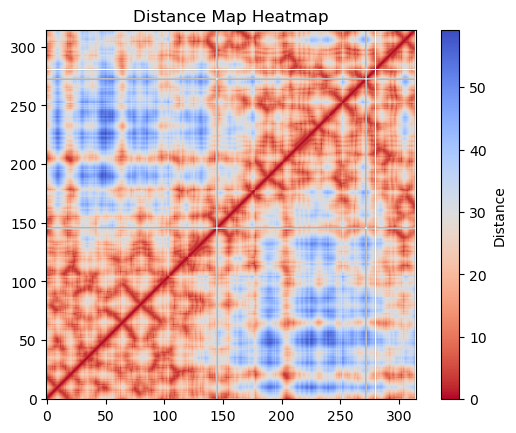

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(distance_map,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Map Heatmap")
plt.show()

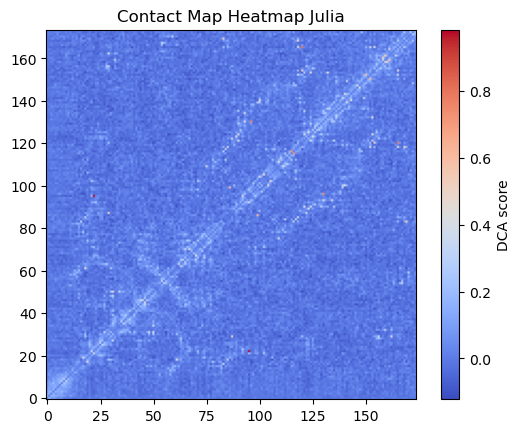

In [9]:
plt.figure()
plt.imshow(contact_map_DCA,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA score")
plt.title("Contact Map Heatmap Julia")
plt.show()

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

folder_path = "Data"

total_distances = []
total_scrores = []

for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence'] 
        #print(sequence)



        distance_map=loaded['distance_map']

        #Extract unique distances (no diagonal, no duplicates)
        distances = distance_map[np.triu_indices_from(distance_map, k=1)]

        # Remove invalid values
        distances = distances[np.isfinite(distances)]
        total_distances.extend(distances)
        # # Plot
        # plt.figure()
        # plt.hist(distances, bins=50, density=True)
        # plt.xlabel("Distance (Å)")
        # plt.ylabel("Density")
        # plt.title("Distance Distribution")
        # plt.show()



        contact_map_DCA=loaded['dca']

        # Extract unique distances (no diagonal, no duplicates)
        distances = contact_map_DCA[np.triu_indices_from(contact_map_DCA, k=1)]
        total_scrores.extend(distances) 
        # # Plot
        # plt.figure()
        # plt.hist(distances, bins=50, density=True)
        # plt.xlabel("DCA Score")
        # plt.ylabel("Density")
        # plt.title("DCA Score Distribution")
        # plt.show()




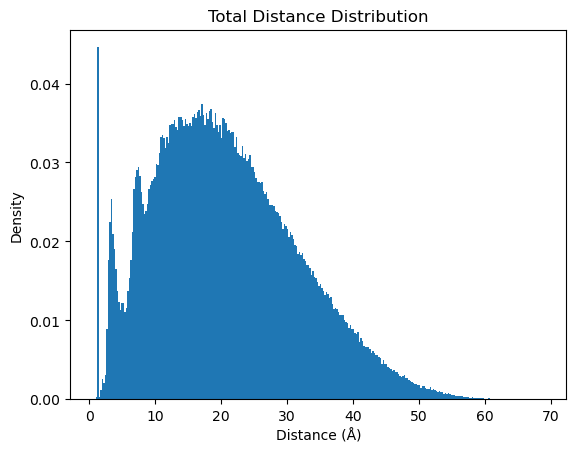

In [2]:
plt.figure()
plt.hist(total_distances, bins=300, density=True)
plt.xlabel("Distance (Å)")
plt.ylabel("Density")
plt.title("Total Distance Distribution")
plt.show()

20.844407489133516 10.825315429915898


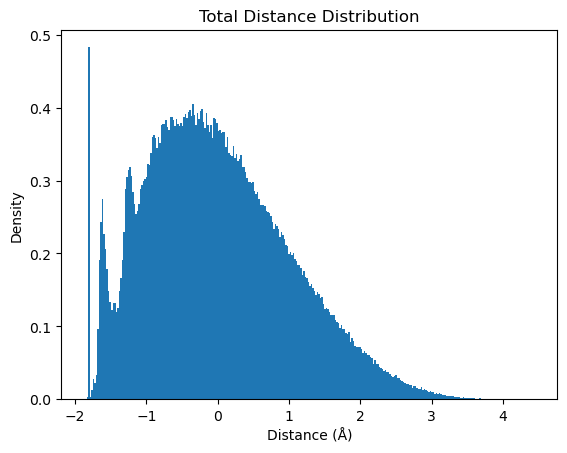

In [3]:
m=min(total_distances)
mean=np.mean(total_distances)
sigma=np.std(total_distances)
print(mean, sigma) 
plt.figure()
plt.hist((np.array(total_distances)-mean)/sigma, bins=300, density=True)
plt.xlabel("Distance (Å)")
plt.ylabel("Density")
plt.title("Total Distance Distribution")
plt.show()

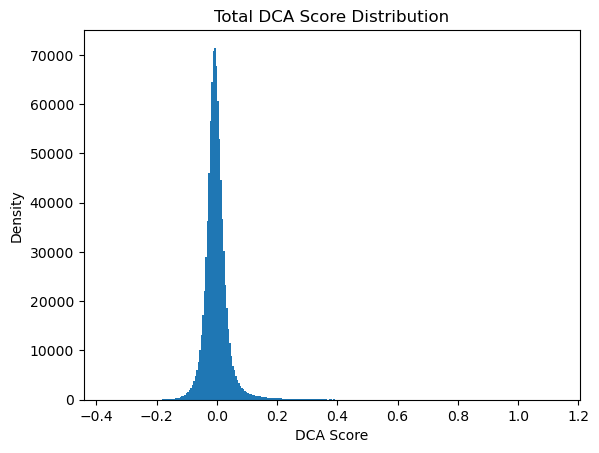

In [4]:
plt.figure()
#t_d = [d for d in total_distances if d > 1.34] 
plt.hist(np.log(np.array(total_scrores)+1), bins=300, density=False)
plt.xlabel("DCA Score")
plt.ylabel("Density")
plt.title("Total DCA Score Distribution")
plt.show()